# Feature engineering 

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import xgboost as xgb
from xgboost import plot_importance, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('fivethirtyeight')

In [ ]:
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
DATA_DIR = os.path.join(ROOT_DIR, 'data')
sales_df = pd.read_csv(os.path.join(DATA_DIR, 'raw', 'sales.csv'))

In [5]:
sales_df.head(10)

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
5,2012-07-09,3548386.46,2787841.68
6,2012-07-10,5234938.62,4044438.84
7,2012-07-11,5582884.78,4338313.07
8,2012-07-12,5734632.02,4458811.27
9,2012-07-13,5309511.71,4143402.78


![Sales Chart](../outputs/images/preprocessing.png)

## 1. Cơ sở lý thuyết (Listing -> Searching -> Understanding)

### 1.1. Data preprocessing

#### a. Handle missing values
- Forward fill (ffill)
- Backward fill (bfill)
- Interpolation (linear / time-based)
- Seasonal fill (theo tuần/tháng)

#### b. Fix missing timestamps (resampling)

#### c. Outlier handling
- IQR filtering
- Z-score
- Winsorization
- domain-based (holiday spike giữ lại)

#### d. Smoothing (noise reduction)
- Moving average
- Exponential smoothing

#### e. Transformation

Khi data skewed:
- log transform
- box-cox
- sqrt transform

### 1.2. Feature engineering
#### a. Lag features 

#### b. Rolling features

#### c. Expanding features

#### d. Calendar features (day, week, month, quarter, year)

#### e. Seasonal features

sin/cos transform

#### f. Trend features

- time index
- cumulative time

#### g. Lag differences

#### h. Target transformation

#### i. Interaction features and External features (Dùng những features thêm ở bảng/cột khác)

Ví dụ:
- Web traffic
    - Web traffic
    - sessions
    - conversion_rate
    - bounce_rate



**NOTE**: Core time series features
- Lags (1,7,30)
- Rolling mean/std
- Calendar features
- Trend index
- Seasonality encoding

**Recommended FE pipeline:** 
1. Sort by time
2. Fill missing dates
3. Create lag features
4. Create rolling stats
5. Add calendar features
6. Merge external data
7. Encode seasonality
8. Train/test split by time

<font color="red">**Lưu ý**</font>: Những lỗi hay sai
1. Random train-test split
2. Leakage (using future info)
3. Scaling before split
4. Using current target as feature
5. Removing holiday spikes

## 2. Pipeline
1. Train/test split
2. Preprocessing
3. Feature extraction
4. Feature selection

In [8]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'])
trend_df = sales_df.groupby('Date')['Revenue'].sum().reset_index()

trend_df

,Date,Revenue
0,2012-07-04,5123547.94
1,2012-07-05,2751773.45
2,2012-07-06,3054029.42
3,2012-07-07,2667930.94
4,2012-07-08,2360851.90
...,...,...
3828,2022-12-27,2100553.66
3829,2022-12-28,3448729.20
3830,2022-12-29,3083944.33
3831,2022-12-30,2884668.76


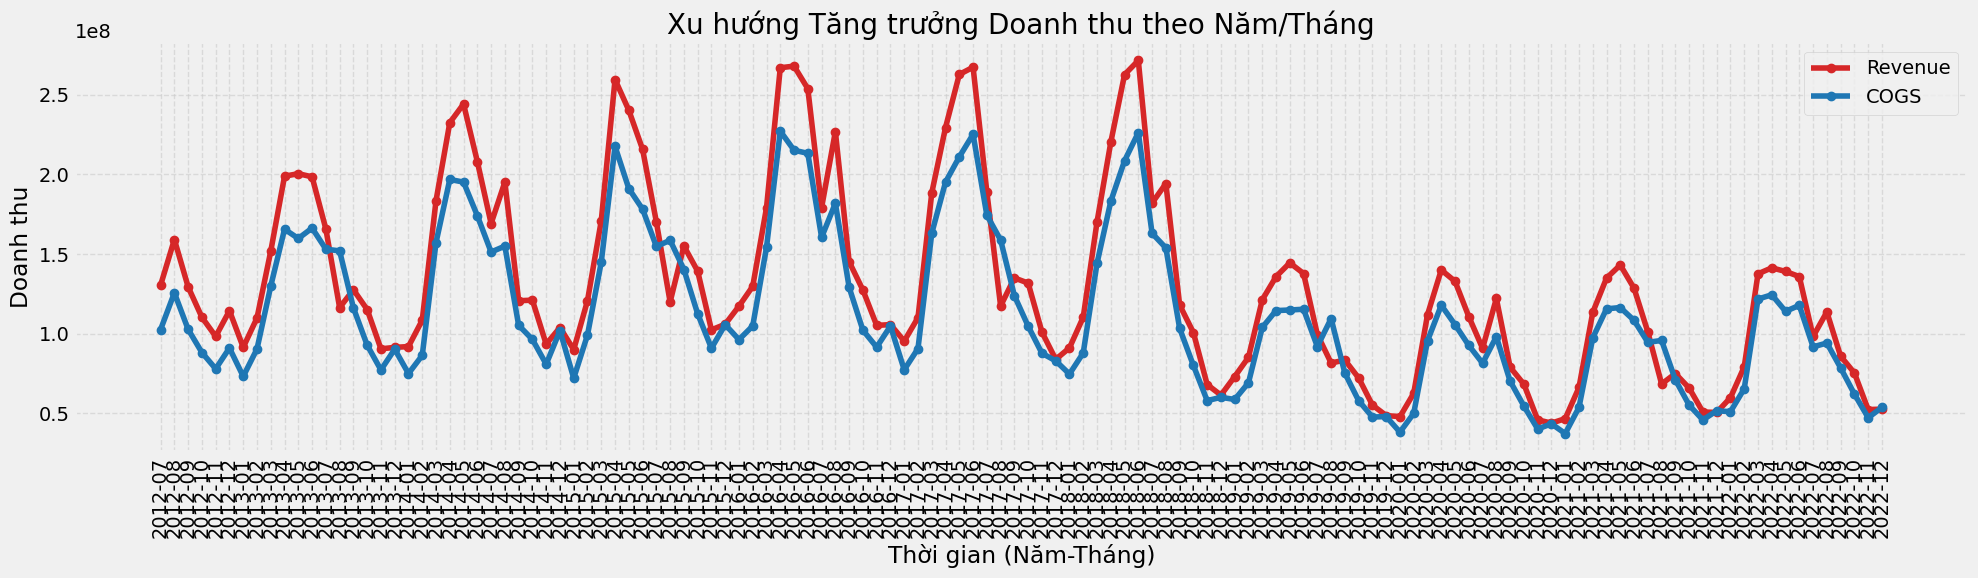

In [ ]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Tạo các cột thời gian để phân tích
sales_df['year_month'] = sales_df['Date'].dt.to_period('M')      # Lấy Năm-Tháng
sales_df['day_of_week'] = sales_df['Date'].dt.dayofweek          # Lấy Thứ (0=Thứ 2, 6=Chủ nhật)
sales_df['month'] = sales_df['Date'].dt.month                    # Lấy Tháng (1 đến 12)

# Tổng hợp Doanh thu theo Năm/Tháng
# trend_df = sales_df.groupby('year_month')['Revenue'].sum().reset_index()
# trend_df['year_month'] = trend_df['year_month'].astype(str) 
trend_df = sales_df.groupby('year_month')[['Revenue', 'COGS']].sum().reset_index()
trend_df['year_month'] = trend_df['year_month'].astype(str) 

fig1, ax1 = plt.subplots(figsize=(20, 6))

ax1.plot(trend_df['year_month'], trend_df['Revenue'], color='tab:red', marker='o')
ax1.plot(trend_df['year_month'], trend_df['COGS'], color='tab:blue', marker='o')
ax1.set_title('Xu hướng Tăng trưởng Doanh thu theo Năm/Tháng', fontsize=20)
ax1.set_xlabel('Thời gian (Năm-Tháng)')
ax1.set_ylabel('Doanh thu')
ax1.tick_params(axis='x', rotation=90)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(['Revenue', 'COGS'], loc='upper right')

fig1.tight_layout()
plt.show()

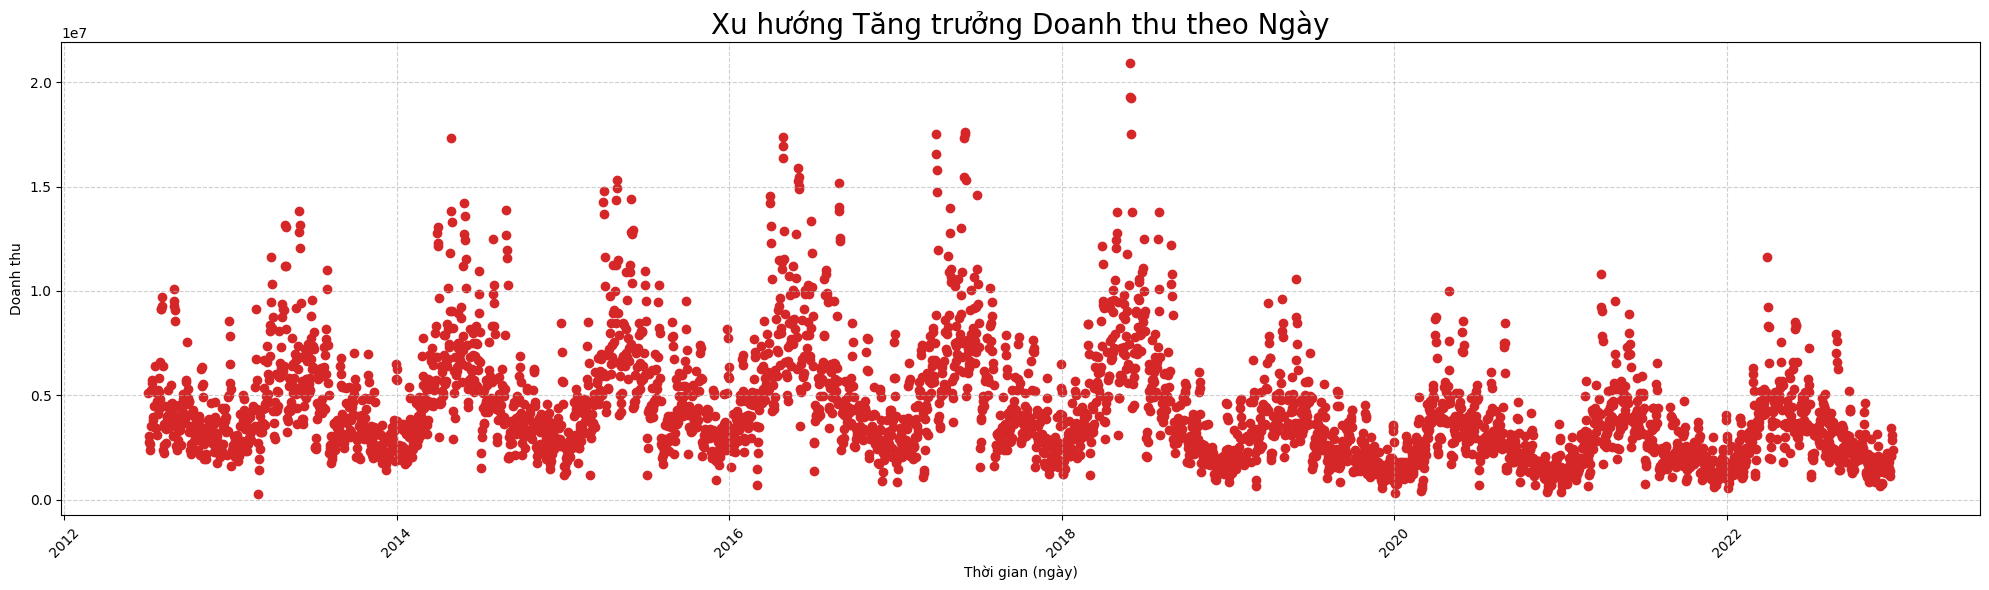

In [17]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

trend_df = sales_df.groupby('Date')['Revenue'].sum().reset_index()

fig1, ax1 = plt.subplots(figsize=(20, 6))

ax1.scatter(
    trend_df['Date'],
    trend_df['Revenue'],
    color='tab:red',
    # marker='o',
    # linewidth=1.5
)

ax1.set_title('Xu hướng Tăng trưởng Doanh thu theo Ngày', fontsize=20)
ax1.set_xlabel("Thời gian (ngày)")
ax1.set_ylabel("Doanh thu")

ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.6)

fig1.tight_layout()
plt.show()

### 2.1. Train/test split

In [24]:
split_date = '01-Jan-2020'
train_set = sales_df.loc[sales_df['Date'] <= split_date].copy()
test_set = sales_df.loc[sales_df['Date'] > split_date].copy()

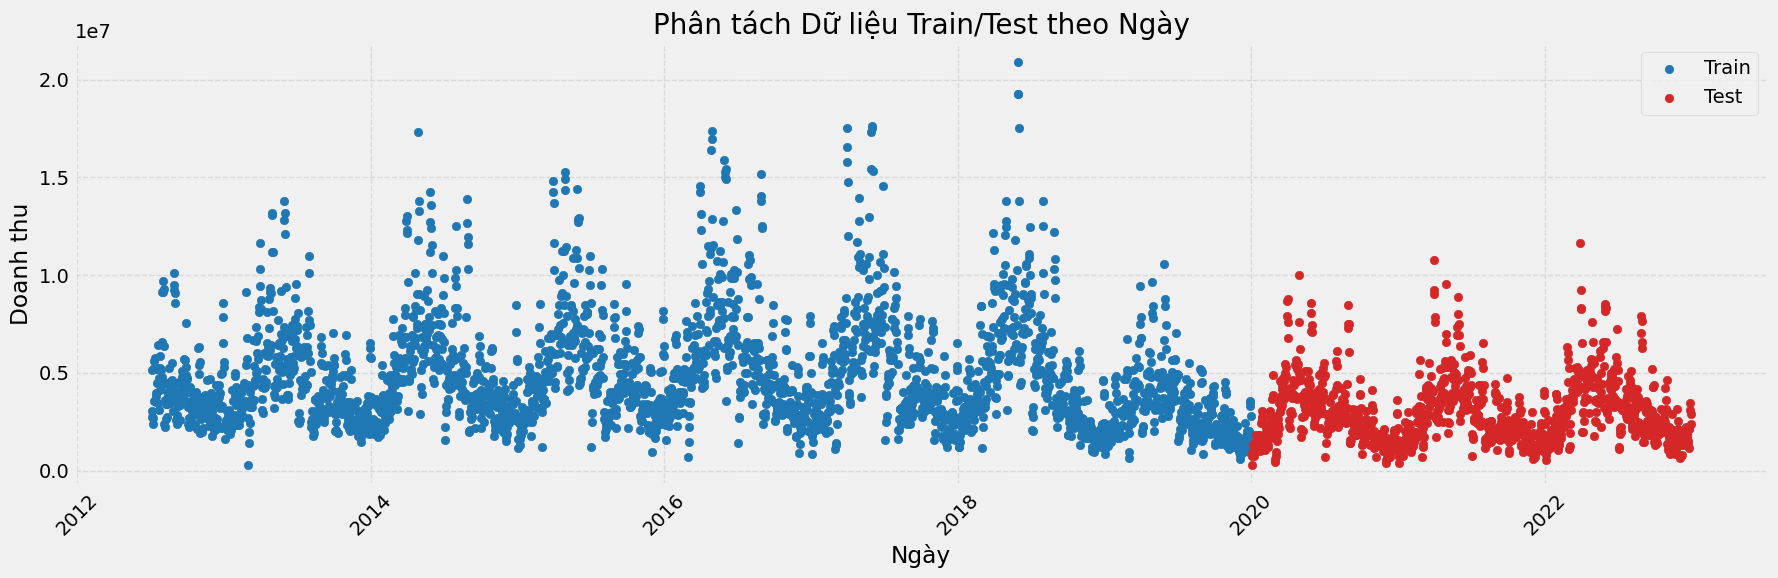

In [29]:
plt.figure(figsize=(18, 6))
plt.scatter(train_set['Date'], train_set['Revenue'], label='Train', color='tab:blue')
plt.scatter(test_set['Date'], test_set['Revenue'], label='Test', color='tab:red')
plt.title('Phân tách Dữ liệu Train/Test theo Ngày', fontsize=20)
plt.xlabel('Ngày')
plt.ylabel('Doanh thu')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

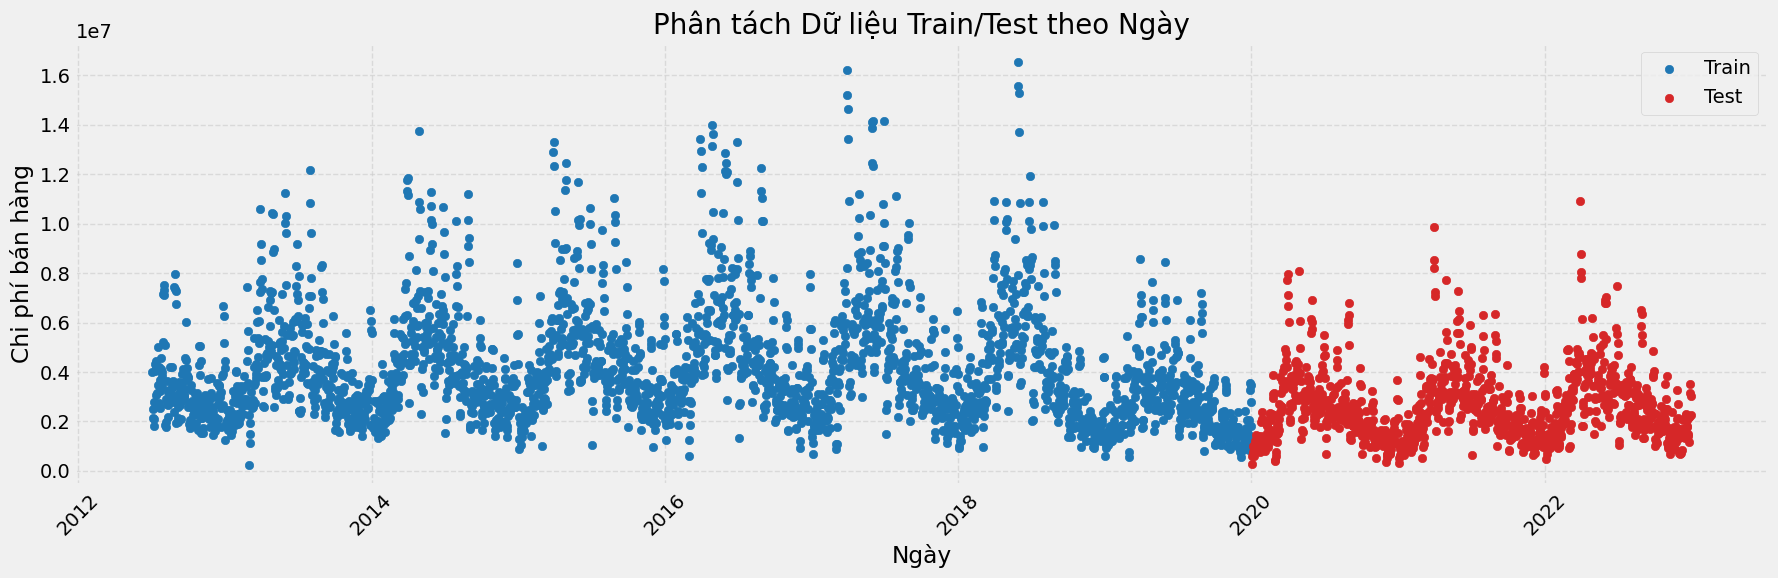

In [30]:
plt.figure(figsize=(18, 6))
plt.scatter(train_set['Date'], train_set['COGS'], label='Train', color='tab:blue')
plt.scatter(test_set['Date'], test_set['COGS'], label='Test', color='tab:red')
plt.title('Phân tách Dữ liệu Train/Test theo Ngày', fontsize=20)
plt.xlabel('Ngày')
plt.ylabel('Chi phí bán hàng')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 2.2. Preprocessing

a. Xử lý Ngoại lai (Outlier Handling): áp dụng Winsorization (giới hạn giá trị ở percentile thứ 95 hoặc 99) hoặc dùng các kỹ thuật scaling kháng nhiễu như RobustScaler.

b. Chuẩn hóa dữ liệu (Scaling): scale đưa dữ liệu về khoảng $[0, 1]$ $\to$ MinMaxScaler hoặc StandardScaler 

**Lưu ý**: Phải fit scaler trên tập Train và chỉ transform trên tập Test để tránh rò rỉ dữ liệu.

c. Target Transformation